# PSS: how do ABA, JA and SA reach RD29?

This tutorial works through a question from the
[SKM publication](https://doi.org/10.1016/j.xplc.2024.100920) (case study 1) with the
Plant Stress Signalling model (PSS):

> ABA induces the expression of *RD29* in Arabidopsis and potato. Adding SA or JA
> weakens this induction, although on their own they have no effect. Where could the
> SA and JA pathways meet the ABA → RD29 pathway?

Along the way, it shows how to:

- load the PSS networks and look at their nodes and edges,
- filter PSS by node type and species,
- find shortest paths and neighbourhoods,
- find nodes by MapMan bin,
- go from functional clusters to genes with a gene network,
- save the results, and export them for DiNAR,
- merge the parallel edges for drawing,
- show the results in Cytoscape.

The Cytoscape cells (the last section) need a running Cytoscape; everything else runs
without it. See the [skm-tools documentation](https://nib-si.github.io/skm-tools) for
more on each function.

PSS is curated continuously, so the networks you download may differ from those this
tutorial was written with: the results printed by the cells can differ from the text.
The `assert` lines check what holds whatever the network contains (e.g. that a path
starts at its source).

In [1]:
import logging
from collections import Counter
from pathlib import Path

import pandas as pd

from skm_tools.annotations import get_nodes_by_mapman
from skm_tools.dinar import write_dinar
from skm_tools.neighbors import get_neighborhood
from skm_tools.paths import get_paths, path_edges, path_subgraph
from skm_tools.persistence import save_graph
from skm_tools.pss import (
    filter_pss_nodes,
    pss_gene_network_to_networkx,
    pss_interaction_network_to_networkx,
    simplify_pss,
)

data_dir = Path("data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

The skm-tools functions report what they did (e.g. how many nodes a filter removed, or
a download) as log messages. Python doesn't show these unless asked; this line shows them:

In [2]:
logging.basicConfig(level="INFO", format="%(levelname)s %(name)s: %(message)s")

## Loading PSS

PSS comes as three networks: the reaction graph (reactions as nodes), the interaction
network (entity → entity influences) and a gene network per species (the interaction
network with functional clusters replaced by their genes). Here we use the interaction
network. The files are downloaded from [skm.nib.si](https://skm.nib.si) the first time,
into `data/`.

In [3]:
pss = pss_interaction_network_to_networkx(data_dir=data_dir)
print(pss)

MultiDiGraph with 749 nodes and 1567 edges


Plant genes are grouped in *functional clusters*, named `short_name[functional_cluster_id]`;
`display_label` has the name to show. A small helper finds nodes by their label:

In [4]:
def find(g, label):
    """The nodes of g with this display_label."""
    return [n for n, d in g.nodes(data=True) if d["display_label"] == label]


RD29 = find(pss, "RD29")[0]
RD29

'RD29[fc00192]'

In [5]:
{k: v for k, v in pss.nodes[RD29].items() if k in ("node_type", "display_label", "description", "pathway", "ath_homologues")}

{'node_type': 'PlantCoding',
 'display_label': 'RD29',
 'description': 'Responsive to Desiccation 29',
 'pathway': 'Stress - Drought',
 'ath_homologues': ['AT5G52300', 'AT5G52310']}

Edges are entity → entity influences through a reaction, keyed by the reaction id. A
node pair can be linked by several reactions:

In [6]:
pd.DataFrame([
    {"source": u, "target": v, "reaction_id": k, **{a: d[a] for a in ("interaction", "reaction_type", "directed")}}
    for u, v, k, d in pss.in_edges(RD29, keys=True, data=True)
])

,source,target,reaction_id,interaction,reaction_type,directed
0,AREB/ABF[fc00397],RD29[fc00192],rx00605,positive-influence,transcriptional/translational activation,True


## Filtering

PSS also covers pathogens (e.g. viral proteins), and functional clusters without genes in
the species we study. We keep the plant node types, and the reactions whose functional
clusters have genes in Arabidopsis or potato. `filter_pss_nodes` changes the network in
place, and returns why each node was removed.

In [7]:
Counter(d["node_type"] for _, d in pss.nodes(data=True))

Counter({'PlantCoding': 438,
         'Metabolite': 136,
         'Complex': 116,
         'ForeignCoding': 12,
         'Process': 10,
         'MetaboliteFamily': 9,
         'PlantAbstract': 8,
         'PlantNonCoding': 8,
         'ForeignNonCoding': 5,
         'ForeignAbiotic': 4,
         'ForeignEntity': 3})

In [8]:
keep_types = ["Complex", "ForeignAbiotic", "Metabolite", "MetaboliteFamily", "PlantAbstract",
              "PlantCoding", "PlantNonCoding", "Process"]

removed = filter_pss_nodes(pss, node_types=keep_types, species=["ath", "stu"])

assert not set(removed) & set(pss)
assert {d["node_type"] for _, d in pss.nodes(data=True)} <= set(keep_types)
Counter(removed.values())

INFO skm_tools.pss: Removed 87 nodes from the network.


Counter({'isolate': 54,
         'wrong node type': 20,
         'species missing': 7,
         'complex component removed': 6})

## Shortest paths

The shortest paths from ABA, JA and SA to RD29:

In [9]:
label = dict(pss.nodes(data="display_label"))

paths = {source: get_paths(pss, source, RD29) for source in ["ABA", "JA", "SA"]}
for source, source_paths in paths.items():
    for p in source_paths:
        assert p[0] == source and p[-1] == RD29
        assert all(pss.has_edge(u, v) for u, v in zip(p, p[1:]))
        print(" → ".join(label[n] for n in p))

ABA → PYL → MYC2 → DELLA → AREB/ABF → RD29
ABA → PYL → PP2C → SNRK2 → AREB/ABF → RD29
JA → JA-Ile → COI1|JA-Ile|SCF → JAZ → DELLA → AREB/ABF → RD29
SA → NPR1 → MYC2 → DELLA → AREB/ABF → RD29


Where do the JA and SA paths join the ABA paths?

In [10]:
on_aba_paths = {n for p in paths["ABA"] for n in p}
for source in ["JA", "SA"]:
    joins = dict.fromkeys(next(label[n] for n in p if n in on_aba_paths) for p in paths[source])
    print(source, "joins the ABA paths at:", ", ".join(joins))

JA joins the ABA paths at: DELLA
SA joins the ABA paths at: MYC2


Every step of a path is a reaction. The edges along the ABA paths, with their reactions:

In [11]:
pd.DataFrame([
    {"source": label[u], "interaction": d["interaction"], "target": label[v],
     "reaction_id": k, "reaction_type": d["reaction_type"]}
    for u, v, k in path_edges(pss, paths["ABA"])
    for d in [pss.edges[u, v, k]]
])

,source,interaction,target,reaction_id,reaction_type
0,ABA,positive-influence,PYL,rx00474,protein activation
1,PYL,negative-influence,MYC2,rx00459,binding/oligomerisation
2,MYC2,negative-influence,DELLA,rx00162,binding/oligomerisation
3,MYC2,positive-influence,DELLA,rx00163,transcriptional/translational activation
4,DELLA,negative-influence,AREB/ABF,rx00608,degradation/secretion
5,AREB/ABF,positive-influence,RD29,rx00605,transcriptional/translational activation
6,PYL,negative-influence,PP2C,rx00475,protein deactivation
7,PP2C,negative-influence,SNRK2,rx00476,protein deactivation
8,SNRK2,positive-influence,AREB/ABF,rx00569,protein activation
9,SNRK2,negative-influence,AREB/ABF,rx00610,transcriptional/translational repression


## Neighbourhoods

What else is DELLA connected to? `get_neighborhood` returns the subnetwork around nodes
(here the first neighbours, in both directions), with each node's `distance`:

In [12]:
DELLA = find(pss, "DELLA")[0]
della = get_neighborhood(pss, DELLA, depth=1)
assert all(d == (0 if n == DELLA else 1) for n, d in della.nodes(data="distance"))
sorted(label[n] for n in della if n != DELLA)

['ABI4',
 'ABI4|RGL2',
 'AREB/ABF',
 'CO',
 'GAI|GI',
 'GA|GID1',
 'GI',
 'JAZ',
 'MYC2',
 'PIF3,4']

## MapMan bins

Nodes are annotated with the MapMan bins (MapMan4) of their Arabidopsis genes, as
`<bin code>_<bin name>`. `get_nodes_by_mapman` finds the nodes in a bin, including its
sub-bins. Bin 10.1 is *Phytohormone action. abscisic acid*:

In [13]:
def bins(node, code=""):
    """The node's MapMan bins (starting with code), shortened for display."""
    return [b.split(" *(")[0] for b in pss.nodes[node]["mapman"] or [] if b.startswith(code)]


for n in get_nodes_by_mapman(pss, "10.1"):
    print(f"{label[n]:10}", bins(n, "10.1"))

AAO        ['10.1.1.7_Phytohormone action.abscisic acid.biosynthesis.abscisic aldehyde oxidase']
ABA2       ['10.1.1.5_Phytohormone action.abscisic acid.biosynthesis.xanthoxin oxidase']
CYP707A3   ['10.1.3.1_Phytohormone action.abscisic acid.conjugation and degradation.abscisic acid hydroxylase']
NCED       ['10.1.1.4_Phytohormone action.abscisic acid.biosynthesis.9-cis-epoxycarotenoid dioxygenase']
PYL        ['10.1.2.1.1.1_Phytohormone action.abscisic acid.perception and signalling.receptor activities.cytoplasm-localized receptor complex.receptor component']
ZEP        ['10.1.1.1_Phytohormone action.abscisic acid.biosynthesis.zeaxanthin epoxidase']


Bin 10.1 has the ABA biosynthesis genes (ZEP, NCED, ABA2, AAO), its breakdown
(CYP707A3) and its receptor (PYL), but of the ABA signalling route to RD29 only PYL. MapMan
classifies genes by their molecular function: the phosphatase PP2C is in the protein
dephosphorylation bins (18.5), the kinase SnRK2 in the phosphorylation bins (18.4), and
AREB/ABF in the transcription factor bins (14.5):

In [14]:
for n in dict.fromkeys(n for p in paths["ABA"] for n in p):
    print(f"{label[n]:10}", bins(n))

ABA        []
PYL        ['10.1.2.1.1.1_Phytohormone action.abscisic acid.perception and signalling.receptor activities.cytoplasm-localized receptor complex.receptor component']
MYC2       ['10.7.2.1.2_Phytohormone action.jasmonic acid.perception and signal transduction.receptor activities.regulatory protein', '14.5.1.2.8_RNA biosynthesis.DNA-binding transcriptional regulation.basic DNA-binding domain.basic helix-loop-helix (bHLH) domain.bHLH class-IIIe transcription factor']
DELLA      ['10.6.2.2_Phytohormone action.gibberellin.perception and signal transduction.DELLA-type transcriptional repressor', '14.5.10.2_RNA biosynthesis.DNA-binding transcriptional regulation.undefined DNA-binding domain.GRAS transcription factor', '26.7.2.1_External stimuli response.salinity.gibberellin-abscisic acid signalling pathways crosstalk.DELLA-type transcription factor']
AREB/ABF   ['14.5.1.1.1.1_RNA biosynthesis.DNA-binding transcriptional regulation.basic DNA-binding domain.basic leucine zipper (bZI

So MapMan bins are good for finding genes of a molecular function (e.g. all receptors, or
all bZIP transcription factors). To find the nodes of a signalling pathway, use the PSS
pathways instead: `all_pathways` has all the pathways of a node (`pathway` only its main
one). Of the ABA route to RD29, these are in the ABA pathway:

In [15]:
aba_pathway = [n for n, d in pss.nodes(data=True)
               if "Hormone - Abscisic acid (ABA)" in (d["all_pathways"] or [])]
print(len(aba_pathway), "nodes in the ABA pathway")
sorted(label[n] for n in aba_pathway if n in on_aba_paths)

35 nodes in the ABA pathway


['AREB/ABF', 'PYL', 'RD29', 'SNRK2']

## From functional clusters to genes

The gene network of a species has the genes of each functional cluster as nodes, so
paths can be followed gene by gene. In the Arabidopsis gene network, the RD29 cluster
(`fc00192`) has these genes:

In [16]:
genes_ath = pss_gene_network_to_networkx(species="ath", data_dir=data_dir)
rd29_genes = [n for n, d in genes_ath.nodes(data=True)
              if "fc00192" in (d.get("functional_cluster_id") or [])]
rd29_genes

['AT5G52300', 'AT5G52310']

In [17]:
gene_paths = get_paths(genes_ath, "ABA", rd29_genes)
assert all(p[0] == "ABA" and p[-1] in rd29_genes for p in gene_paths)
print(len(gene_paths), "gene-level shortest paths, e.g.:")
gene_label = dict(genes_ath.nodes(data="display_label"))
for p in gene_paths[:3]:
    print(" → ".join(f"{gene_label[n]} ({n})" if n != gene_label[n] else n for n in p))

128 gene-level shortest paths, e.g.:
ABA → PYL (AT1G01360) → MYC2 (AT1G32640) → DELLA (AT5G17490) → AREB/ABF (AT1G49720) → RD29 (AT5G52300)
ABA → PYL (AT2G40330) → MYC2 (AT1G32640) → DELLA (AT5G17490) → AREB/ABF (AT1G49720) → RD29 (AT5G52300)
ABA → PYL (AT1G01360) → MYC2 (AT1G32640) → DELLA (AT3G03450) → AREB/ABF (AT1G49720) → RD29 (AT5G52300)


## Saving

The path subnetwork can be saved for later (pickle or JSON), and the gene network
exported as a [DiNAR](https://github.com/NIB-SI/DiNAR) custom network, to show
expression data on it (one cluster per pathway):

In [18]:
all_paths = [p for source_paths in paths.values() for p in source_paths]
paths_net = path_subgraph(pss, all_paths)
assert {n for p in all_paths for n in p} == set(paths_net)
save_graph(paths_net, output_dir / "pss-paths-to-RD29.json", format="json")

nodes_file, edges_file = output_dir / "pss-ath-dinar-nodes.txt", output_dir / "pss-ath-dinar-edges.txt"
write_dinar(genes_ath, nodes_file, edges_file, clusters="pathway")
assert pd.read_csv(edges_file, sep="\t")["reactionType"].str[:4].isin(["act_", "inh_", "unk_"]).all()
print(paths_net)

MultiDiGraph with 14 nodes and 18 edges


## Conclusion

The publication found that JA meets the ABA pathway through a protein–protein
interaction of the JA-responsive transcription factor MYC2 with the ABA receptor PYL6
(reaction rx00459), which may deplete PYL and so limit ABA perception; and that SA meets
it through the interaction of the SA receptor NPR1 with MYC2 (rx00432). Experiments then
confirmed that JA and SA together attenuate the ABA induction of RD29.

Since then PSS has grown, and the shortest paths have changed. Are these two reactions
still on the paths?

In [19]:
for reaction in ["rx00459", "rx00432"]:
    on = [s for s, ps in paths.items() if any(k == reaction for _, _, k in path_edges(pss, ps))]
    print(reaction, "is on the shortest paths from:", ", ".join(on) or "none")

rx00459 is on the shortest paths from: ABA
rx00432 is on the shortest paths from: SA


At the time of writing, NPR1 → MYC2 (rx00432) is still on SA's path to RD29, and the
MYC2–PYL interaction (rx00459) is now on an ABA path (ABA → PYL → MYC2 → DELLA). The
shortest JA path, however, now goes through JAZ to DELLA: JA can meet the ABA pathway
through DELLA too. Shortest paths give the most direct connections in the current model;
for more context, look at the neighbourhoods of the paths (above, and in Cytoscape below).

## Simplifying for drawing

The interaction network has an edge for every reaction, so two nodes that take part in
several reactions together are joined by several parallel edges. That is needed for the
analyses above (e.g. to know which reaction a path step is), but clutters a drawing.
`simplify_pss` merges them into one edge per node pair: the merged edge keeps all the
reaction ids, and for the other attributes one value (e.g. `unknown-influence` when a
positive and a negative influence are merged; see its documentation for the rule):

In [20]:
pss_simple = simplify_pss(pss)
assert set(pss_simple) == set(pss)
assert set(pss_simple.edges()) == {(u, v) for u, v in pss.edges()}
merged = {(u, v): d for u, v, d in pss_simple.edges(data=True) if len(d["reaction_id"]) > 1}
print(pss.number_of_edges(), "edges in PSS,", pss_simple.number_of_edges(), "after merging;",
      len(merged), "of them merged from several reactions")

INFO skm_tools.pss: Merged edges with differing values: influence_sbo (17), interaction (17), target_role (16), evidence_sentence (13), experimental_techniques (12), source_location_putative (8), reaction_sbo (8), reaction_type (8), source_role (7), target_location_putative (6), directed (6), reaction_effect (6), target_form (4), source_form (3), target_location (3), source_location (2), reaction_mechanism (1). See the docstring for the value kept, and verbose=True for details.


1363 edges in PSS, 1306 after merging; 42 of them merged from several reactions


For example, the edges along the paths to RD29 that were merged:

In [21]:
for u, v in dict.fromkeys(e[:2] for e in path_edges(pss, all_paths)):
    if (u, v) in merged:
        d = merged[u, v]
        print(f"{label[u]} → {label[v]}: {', '.join(d['reaction_id'])} ({d['interaction']})")

MYC2 → DELLA: rx00162, rx00163 (unknown-influence)
SNRK2 → AREB/ABF: rx00569, rx00610 (unknown-influence)
SA → NPR1: rx00114, rx00422, rx00423 (unknown-influence)


A merged edge whose reactions have different signs becomes an `unknown-influence`. To keep
them apart (e.g. to colour edges by sign), merge only edges with the same interaction:
`simplify_pss(pss, split_on_attrs="interaction")`.

## Cytoscape

The rest of this tutorial needs a running Cytoscape (3.10 or later), and the `cytoscape`
extra (`pip install "skm-tools[cytoscape]"`). We load the simplified PSS with the SKM style,
highlight the paths from ABA, JA and SA in different colours, and make a subnetwork with
only the paths.

In [22]:
# ci-skip: needs a running Cytoscape
import py4cytoscape as p4c
from IPython.display import Image

from skm_tools import cytoscape_utils as cu

p4c.cytoscape_ping()

DEBUG py4...: Calling cytoscape_ping()


DEBUG py4...: ǀCalling cytoscape_version_info(base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀCalling cyrest_get('version', base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: Attempting to direct connect to Cytoscape on http://127.0.0.1:1234/v1


DEBUG py4...: Detected py4cytoscape running on Cytoscape workstation


...

DEBUG py4...: ǀǀReturning 'cyrest_get': {'apiVersion': 'v1', 'cytoscapeVersion': '3.10.2'}


DEBUG py4...: ǀReturning 'cytoscape_version_info': {'apiVersion': 'v1', 'cytoscapeVersion': '3.10.2', 'automationAPIVersion': '1.13.0', 'py4cytoscapeVersion': '1.13.0'}


DEBUG py4...: Returning 'cytoscape_ping': 'You are connected to Cytoscape!'


DEBUG py4...: --------------------


'You are connected to Cytoscape!'

In [23]:
# ci-skip: needs a running Cytoscape
suid = cu.load_network(pss_simple, title="PSS (filtered, simplified)", collection="Tutorial: PSS", style="skm")

DEBUG py4...: Calling create_network_from_networkx(<networkx.classes.digraph.DiGraph object at 0x7fa8dc3c1940>, title='PSS (filtered, simplified)', collection='Tutorial: PSS')


DEBUG py4...: ǀCalling create_network_from_data_frames(nodes=            node_type display_label short_name  \
0          Metabolite     12,13-EOT        NaN   
1          Metabolite      12-OH-JA        NaN   
2          Metabolite  12-OH-JA-Ile        NaN   
3          Metabolite       13-HPOT        NaN   
4          Metabolite     3H3PP-CoA        NaN   
..                ...           ...        ...   
657        Metabolite  tRNA-adenine        NaN   
658        Metabolite            tZ        NaN   
659  MetaboliteFamily  tZ-glucoside        NaN   
660        Metabolite   tZ-riboside        NaN   
661  MetaboliteFamily   tZ-ribotide        NaN   

                                              synonyms  \
0    [10,11-EHT, epoxylinolenic acid, (9Z,13S,15Z)-...   
1            [tuberonic acid, 12-Hydroxyjasmonic acid]   
2                                                 None   
3    [13-HPOT, 13(S)-HPOT, 13(S)-HPOTE, (9Z,11E,15Z...   
4                                               

DEBUG py4...: ǀǀCalling cyrest_post('networks', parameters={'title': 'PSS (filtered, simplified)', 'collection': 'Tutorial: PSS'}, body={'data': [{'name': 'PSS (filtered, simplified)'}], 'elements': {'nodes': [{'data': {'id': '12,13-EOT'}}, {'data': {'id': '12-OH-JA'}}, {'data': {'id': '12-OH-JA-Ile'}}, {'data': {'id': '13-HPOT'}}, {'data': {'id': '3H3PP-CoA'}}, {'data': {'id': '3O3PP-CoA'}}, {'data': {'id': '4CL[fc00324]'}}, {'data': {'id': '5-phosphomevalonate'}}, {'data': {'id': "8' OH-ABA"}}, {'data': {'id': "9-cis-10'-apo-beta-carotenal"}}, {'data': {'id': '9-cis-Violaxanthin'}}, {'data': {'id': '9-cis-beta-carotene'}}, {'data': {'id': 'AAO[fc00006]'}}, {'data': {'id': 'ABA'}}, {'data': {'id': 'ABA-GE'}}, {'data': {'id': 'ABA2[fc00019]'}}, {'data': {'id': 'ABF1|IDD14'}}, {'data': {'id': 'ABF2|IDD14'}}, {'data': {'id': 'ABF3|IDD14'}}, {'data': {'id': 'ABF4|IDD14'}}, {'data': {'id': 'ABI4[fc00484]'}}, {'data': {'id': 'ABI4|RGL2'}}, {'data': {'id': 'ABI5[fc00485]'}}, {'data': {'id': 

DEBUG py4...: ǀǀHTTP POST(http://127.0.0.1:1234/v1/networks), params: {'title': 'PSS (filtered, simplified)', 'collection': 'Tutorial: PSS'}, json: {'data': [{'name': 'PSS (filtered, simplified)'}], 'elements': {'nodes': [{'data': {'id': '12,13-EOT'}}, {'data': {'id': '12-OH-JA'}}, {'data': {'id': '12-OH-JA-Ile'}}, {'data': {'id': '13-HPOT'}}, {'data': {'id': '3H3PP-CoA'}}, {'data': {'id': '3O3PP-CoA'}}, {'data': {'id': '4CL[fc00324]'}}, {'data': {'id': '5-phosphomevalonate'}}, {'data': {'id': "8' OH-ABA"}}, {'data': {'id': "9-cis-10'-apo-beta-carotenal"}}, {'data': {'id': '9-cis-Violaxanthin'}}, {'data': {'id': '9-cis-beta-carotene'}}, {'data': {'id': 'AAO[fc00006]'}}, {'data': {'id': 'ABA'}}, {'data': {'id': 'ABA-GE'}}, {'data': {'id': 'ABA2[fc00019]'}}, {'data': {'id': 'ABF1|IDD14'}}, {'data': {'id': 'ABF2|IDD14'}}, {'data': {'id': 'ABF3|IDD14'}}, {'data': {'id': 'ABF4|IDD14'}}, {'data': {'id': 'ABI4[fc00484]'}}, {'data': {'id': 'ABI4|RGL2'}}, {'data': {'id': 'ABI5[fc00485]'}}, {'da

DEBUG py4...: ǀǀOK[200], content: {"networkSUID":28546}


...

DEBUG py4...: ǀHTTP GET(http://127.0.0.1:1234/v1/apply/styles/SKM/28546)


DEBUG py4...: ǀOK[200], content: {"message":"Visual Style applied."}


DEBUG py4...: ǀReturning 'cyrest_get': {'message': 'Visual Style applied.'}


DEBUG py4...: Returning 'set_visual_style': {'message': 'Visual Style applied.'}


DEBUG py4...: --------------------


Highlight each source's paths in its own colour. `highlight_path` returns the nodes and
edges it highlighted; passing them to the next calls as `skip_nodes` and `skip_edges`
keeps the paths from JA and SA from painting over the ABA paths where they meet:

In [24]:
# ci-skip: needs a running Cytoscape
colors = {"ABA": "#E41A1C", "JA": "#377EB8", "SA": "#4DAF4A"}
done_nodes, done_edges = [], []
for source, source_paths in paths.items():
    for p in source_paths:
        nodes, edges = cu.highlight_path(p, colors[source], skip_nodes=done_nodes,
                                         skip_edges=done_edges, network=suid)
        done_nodes += nodes
        done_edges += edges

DEBUG py4...: Calling get_table_columns(table='node', columns=['name'], network=28546)


DEBUG py4...: ǀCalling get_network_suid(28546, base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀCalling cyrest_get('networks', base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀHTTP GET(http://127.0.0.1:1234/v1/networks)


DEBUG py4...: ǀǀOK[200], content: [128,17633,28546,709,15590,555,268,12717,27629,11094,13946,11420,413]


...

DEBUG py4...: ǀǀOK[200], content: 


DEBUG py4...: ǀǀReturning 'cyrest_put': ''


DEBUG py4...: ǀReturning 'set_edge_property_bypass': ''


DEBUG py4...: Returning 'set_edge_color_bypass': ''


DEBUG py4...: --------------------


DEBUG py4...: Calling get_table_columns(table='node', columns=['name'], network=28546)


DEBUG py4...: ǀCalling get_network_suid(28546, base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀCalling cyrest_get('networks', base_url='http://127.0.0.1:1234/v1')


DEBUG py4...: ǀǀHTTP GET(http://127.0.0.1:1234/v1/networks)


DEBUG py4...: ǀǀOK[200], content: [128,17633,28546,709,15590,555,268,12717,27629,11094,13946,11420,413]


...

DEBUG py4...: ǀHTTP POST(http://127.0.0.1:1234/v1/commands/view/export%20png), json: {'allGraphicsDetails': 'True', 'Zoom': '200', 'outputFile': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/pss-paths-to-RD29.png', 'view': 'SUID:38682'}


DEBUG py4...: ǀOK[200], content: {
 "data": {"file":"/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/pss-paths-to-RD29.png"},
 "errors":[]
}


DEBUG py4...: ǀReturning 'commands_post': {'file': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/pss-paths-to-RD29.png'}


DEBUG py4...: Returning 'export_image': {'file': '/home/cbleker/research/NIB/skm/skm-tools/tutorials/output/pss-paths-to-RD29.png'}


DEBUG py4...: --------------------


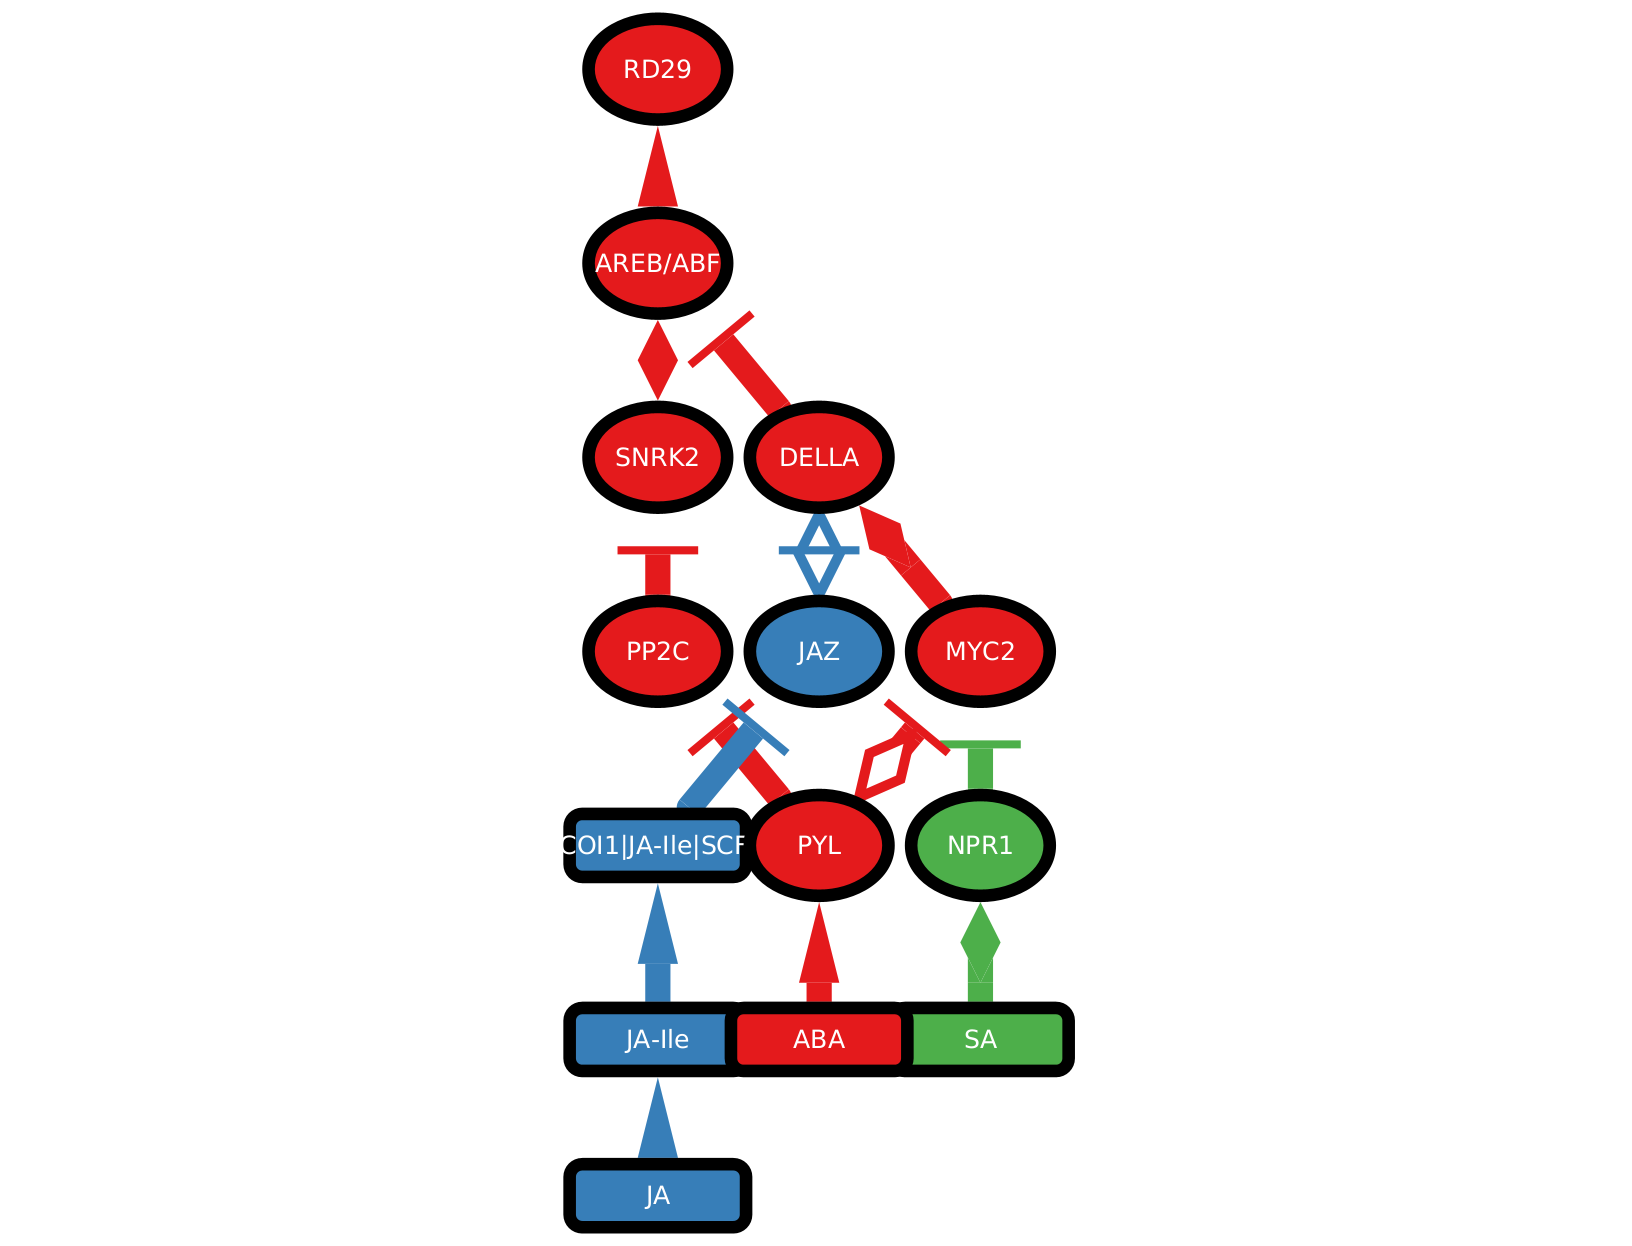

In [25]:
# ci-skip: needs a running Cytoscape
paths_suid = cu.subnetwork_edge_induced_from_paths(pss_simple, all_paths, suid, name="Paths to RD29")
p4c.layout_network("hierarchical", network=paths_suid)
image = cu.export_network(output_dir / "pss-paths-to-RD29.png", format="PNG", zoom=200, network=paths_suid)
Image(image)